# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Muhammad Firman Ardiansyah
- **Email:** xfiranardiansyah2305@gmail.com
- **ID Dicoding:** cdcc012d6y1245

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

## PERTANYAAN

- **Pertanyaan 1:** Bagaimana pengaruh rasio biaya pengiriman terhadap harga barang (Shipping-to-Price Ratio) bagi pelanggan di wilayah luar pulau (Northeast/North Brazil) selama tahun 2018, dan pada titik rasio berapa skor kepuasan pelanggan (review score) mulai menurun drastis di bawah 3.0

- Specific: Fokus pada kaitan antara biaya logistik vs harga barang di wilayah spesifik.
- Measurable: Menggunakan metrik rasio (%) dan rata-rata skor review (1-5).
- Action-Oriented: Jika ditemukan titik jenuh biaya ongkir, perusahaan bisa memberikan subsidi ongkir atau mencari gudang regional di wilayah tersebut.
- Relevant: Ongkir yang mahal seringkali menjadi pembatal transaksi terbesar di e-commerce.
- Time-bound: Terbatas pada data transaksi tahun 2018.

---

- **Pertanyaan 2:** Berapa lama rata-rata durasi validasi pembayaran (dari pembelian ke approval) untuk metode 'boleto' dibandingkan kartu kredit pada periode Flash Sale (Mei-Juni 2018), dan apakah keterlambatan validasi di atas 24 jam berkontribusi pada peningkatan pembatalan pesanan (order canceled) sebesar 10%?
- Specific: Fokus pada pengaruh durasi approval pembayaran terhadap status pembatalan.
- Measurable: Mengukur durasi dalam jam dan persentase pembatalan (10%).
- Action-Oriented: Mengoptimalkan sistem integrasi bank untuk metode boleto jika terbukti menghambat proses.
- Relevant: Memastikan efisiensi sistem pembayaran untuk menjaga stok barang (inventory).
- Time-bound: Periode spesifik Mei hingga Juni 2018.

## Import Semua Packages/Library yang Digunakan

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Data Wrangling

### Gathering Data

#### Load df ...

In [49]:
# Load dataset dari folder data/
customers_df = pd.read_csv("data/customers_dataset.csv")
geolocation_df=pd.read_csv("data/geolocation_dataset.csv")
order_items_df = pd.read_csv("data/order_items_dataset.csv")
order_payments_df = pd.read_csv("data/order_payments_dataset.csv")
order_reviews_df = pd.read_csv("data/order_reviews_dataset.csv")
orders_df = pd.read_csv("data/orders_dataset.csv")
category_translation_df = pd.read_csv("data/product_category_name_translation.csv")
products_df = pd.read_csv("data/products_dataset.csv")
seller_df=pd.read_csv("data/sellers_dataset.csv")

In [50]:
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [51]:
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [52]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [53]:
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [54]:
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [55]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [56]:
category_translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [57]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [58]:
seller_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:** (Opsional)
- Dataset ini terdiri dari berbagai tabel relasional yang mencakup informasi pelanggan, pesanan, item produk, hingga ulasan.  
- Kolom order_id menjadi kunci utama (primary key) yang menghubungkan sebagian besar tabel untuk analisis lebih mendalam.

### Assessing Data

#### Identifying ... problem

In [59]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [60]:
geolocation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [61]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [62]:
order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [63]:
order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [64]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [65]:
category_translation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [66]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [67]:
seller_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [68]:
datasets = {
    "customers": customers_df,
    "geolocation": geolocation_df,
    "order_items": order_items_df,
    "order_payments": order_payments_df,
    "order_reviews": order_reviews_df,
    "orders": orders_df,
    "category_translation": category_translation_df,
    "products": products_df,
    "sellers": seller_df
}

In [69]:
print("=== BERAPA MISSING VALUE DARI DATA E-COMMERCE ===")
for name, df in datasets.items():
    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0]
    
    if not null_cols.empty:
        print(f"\nDataset: {name}")
        for col, count in null_cols.items():
            pct = (count / len(df)) * 100
            print(f" - {col}: {count} data kosong ({pct:.2f}%)")
    else:
        print(f"\nDataset: {name} -> Aman (0 missing)")

=== BERAPA MISSING VALUE DARI DATA E-COMMERCE ===

Dataset: customers -> Aman (0 missing)

Dataset: geolocation -> Aman (0 missing)

Dataset: order_items -> Aman (0 missing)

Dataset: order_payments -> Aman (0 missing)

Dataset: order_reviews
 - review_comment_title: 87656 data kosong (88.34%)
 - review_comment_message: 58247 data kosong (58.70%)

Dataset: orders
 - order_approved_at: 160 data kosong (0.16%)
 - order_delivered_carrier_date: 1783 data kosong (1.79%)
 - order_delivered_customer_date: 2965 data kosong (2.98%)

Dataset: category_translation -> Aman (0 missing)

Dataset: products
 - product_category_name: 610 data kosong (1.85%)
 - product_name_lenght: 610 data kosong (1.85%)
 - product_description_lenght: 610 data kosong (1.85%)
 - product_photos_qty: 610 data kosong (1.85%)
 - product_weight_g: 2 data kosong (0.01%)
 - product_length_cm: 2 data kosong (0.01%)
 - product_height_cm: 2 data kosong (0.01%)
 - product_width_cm: 2 data kosong (0.01%)

Dataset: sellers -> Aman (

#### DUPLIKAT

In [70]:
print("=== PENGECEKAN DUPLIKAT ===")
for name, df in datasets.items():
    dup_count = df.duplicated().sum()
    status = "⚠️ PERLU DIBERSIHKAN" if dup_count > 0 else "✅ BERSIH"
    print(f"{name:20}: {dup_count:>8} baris duplikat [{status}]")

=== PENGECEKAN DUPLIKAT ===
customers           :        0 baris duplikat [✅ BERSIH]
geolocation         :   261831 baris duplikat [⚠️ PERLU DIBERSIHKAN]
order_items         :        0 baris duplikat [✅ BERSIH]
order_payments      :        0 baris duplikat [✅ BERSIH]
order_reviews       :        0 baris duplikat [✅ BERSIH]
orders              :        0 baris duplikat [✅ BERSIH]
category_translation:        0 baris duplikat [✅ BERSIH]
products            :        0 baris duplikat [✅ BERSIH]
sellers             :        0 baris duplikat [✅ BERSIH]


In [71]:
# 1. Cek jumlah duplikat yang sama persis di seluruh kolom
total_exact_duplicates = geolocation_df.duplicated().sum()
print(f"Jumlah duplikat persis (seluruh kolom sama): {total_exact_duplicates}")

# 2. Menampilkan contoh baris yang duplikat untuk melihat isinya secara manual
# Kita urutkan berdasarkan zip_code agar baris yang sama berkumpul
duplicates_view = geolocation_df[geolocation_df.duplicated(keep=False)].sort_values(by='geolocation_zip_code_prefix')
print("\nSampel baris yang duplikat:")
display(duplicates_view.head(10))

# 3. Cek apakah ada zip_code yang sama tapi memiliki koordinat (lat/lng) berbeda
# Ini penting untuk mengetahui apakah ada variasi data di bawah satu zip_code_prefix
unique_coords_per_zip = geolocation_df.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'nunique',
    'geolocation_lng': 'nunique'
})
conflicting_data = unique_coords_per_zip[(unique_coords_per_zip['geolocation_lat'] > 1) | (unique_coords_per_zip['geolocation_lng'] > 1)]
print(f"\nJumlah zip_code_prefix yang punya lebih dari satu koordinat unik: {len(conflicting_data)}")

Jumlah duplikat persis (seluruh kolom sama): 261831

Sampel baris yang duplikat:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
851,1001,-23.549825,-46.633970,sao paulo,SP
1062,1001,-23.550498,-46.634338,sao paulo,SP
1246,1001,-23.549292,-46.633559,sao paulo,SP
897,1001,-23.549292,-46.633559,sao paulo,SP
99,1001,-23.549292,-46.633559,sao paulo,SP
864,1001,-23.549825,-46.633970,sao paulo,SP
771,1001,-23.550498,-46.634338,sao paulo,SP
818,1001,-23.551337,-46.634027,sao paulo,SP
1384,1001,-23.549292,-46.633559,sao paulo,SP
429,1001,-23.550498,-46.634338,sao paulo,SP



Jumlah zip_code_prefix yang punya lebih dari satu koordinat unik: 17781


#### DESCRIBE

In [72]:
for name, df in datasets.items():
    print(f"--- Statistik Deskriptif: {name} ---")
    # include='all' menampilkan ringkasan untuk tipe data numerik & objek
    display(df.describe(include='all'))
    print("\n" + "="*50 + "\n")

--- Statistik Deskriptif: customers ---


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN




--- Statistik Deskriptif: geolocation ---


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,3.657417e+04,-2.117615e+01,-4.639054e+01,NaN,NaN
std,3.054934e+04,5.715866e+00,4.269748e+00,NaN,NaN
min,1.001000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,1.107500e+04,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,2.653000e+04,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,6.350400e+04,-1.997962e+01,-4.376771e+01,NaN,NaN




--- Statistik Deskriptif: order_items ---


...

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1




--- Statistik Deskriptif: products ---


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000




--- Statistik Deskriptif: sellers ---


,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,3442f8959a84dea7ee197c632cb2df15,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


#### CEK KONSISTEN

In [73]:
print("=== PENGECEKAN KONSISTENSI NAMA KOTA (Casing Check) ===")
# Kita membandingkan jumlah nilai unik asli dengan jumlah nilai unik jika semua huruf dikecilkan
city_columns = {
    "Customers": customers_df['customer_city'],
    "Sellers": seller_df['seller_city'],
    "Geolocation": geolocation_df['geolocation_city']
}

for label, col in city_columns.items():
    original_unique = col.nunique()
    lowercase_unique = col.str.lower().nunique()
    
    print(f"Dataset {label}:")
    print(f" - Jumlah unik asli: {original_unique}")
    print(f" - Jumlah unik jika lowercase: {lowercase_unique}")
    
    if original_unique != lowercase_unique:
        print(f" -> TEMUAN: Ada inkonsistensi huruf kapital (data ganda). Perlu Cleaning.")
    else:
        print(f" -> Aman: Nama kota sudah konsisten.")
    print("-" * 30)

print("\n=== PENGECEKAN AKURASI NILAI (Harga & Biaya <= 0) ===")
# Mengecek nilai yang tidak masuk akal (gratis atau negatif) pada kolom finansial
financial_checks = [
    (order_items_df, 'price'),
    (order_items_df, 'freight_value'),
    (order_payments_df, 'payment_value')
]

for df, col in financial_checks:
    invalid_data = df[df[col] <= 0]
    print(f"Kolom {col}: ditemukan {len(invalid_data)} baris dengan nilai <= 0.")
    if len(invalid_data) > 0:
        display(invalid_data.head())

=== PENGECEKAN KONSISTENSI NAMA KOTA (Casing Check) ===
Dataset Customers:
 - Jumlah unik asli: 4119
 - Jumlah unik jika lowercase: 4119
 -> Aman: Nama kota sudah konsisten.
------------------------------
Dataset Sellers:
 - Jumlah unik asli: 611
 - Jumlah unik jika lowercase: 611
 -> Aman: Nama kota sudah konsisten.
------------------------------
Dataset Geolocation:
 - Jumlah unik asli: 8011
 - Jumlah unik jika lowercase: 8011
 -> Aman: Nama kota sudah konsisten.
------------------------------

=== PENGECEKAN AKURASI NILAI (Harga & Biaya <= 0) ===
Kolom price: ditemukan 0 baris dengan nilai <= 0.
Kolom freight_value: ditemukan 383 baris dengan nilai <= 0.


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
114,00404fa7a687c8c44ca69d42695aae73,1,53b36df67ebb7c41585e8d54d6772e08,7d13fca15225358621be4086e1eb0964,2018-05-15 04:31:26,99.9,0.0
258,00a870c6c06346e85335524935c600c0,1,aca2eb7d00ea1a7b8ebd4e68314663af,955fee9216a65b617aa5c0531780ce60,2018-05-14 00:14:29,69.9,0.0
483,011c899816ea29773525bd3322dbb6aa,1,53b36df67ebb7c41585e8d54d6772e08,7d13fca15225358621be4086e1eb0964,2018-05-07 05:30:45,99.9,0.0
508,012b3f6ab7776a8ab3443a4ad7bef2e6,1,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2018-05-09 21:30:50,53.9,0.0
509,012b3f6ab7776a8ab3443a4ad7bef2e6,2,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2018-05-09 21:30:50,53.9,0.0


Kolom payment_value: ditemukan 9 baris dengan nilai <= 0.


,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0


#### OUTLIER

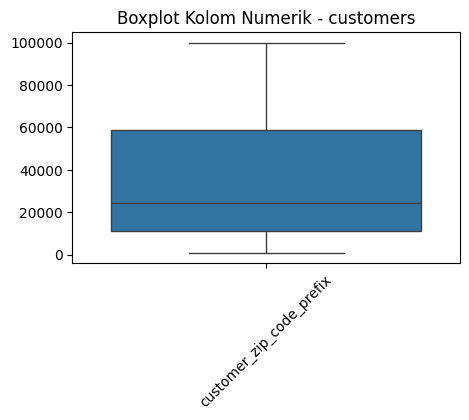

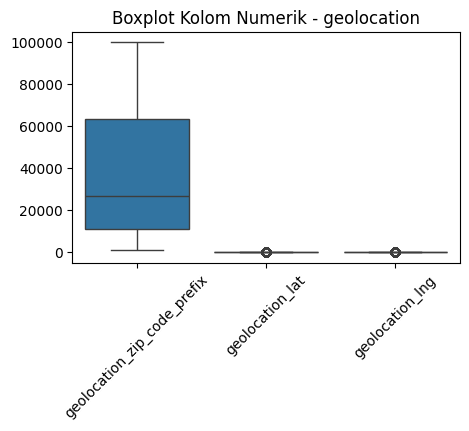

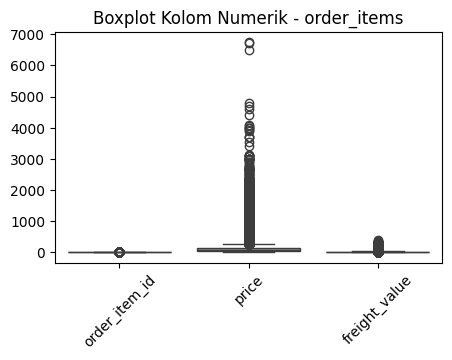

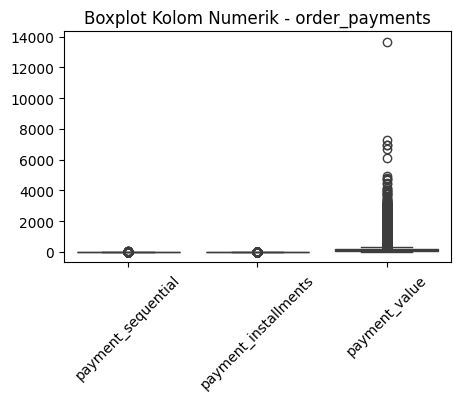

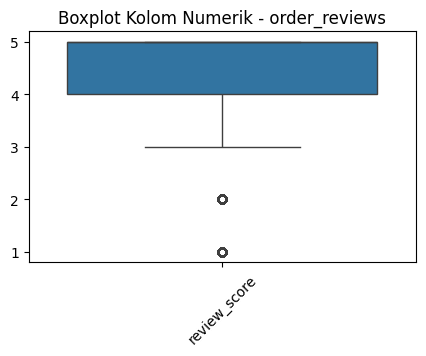

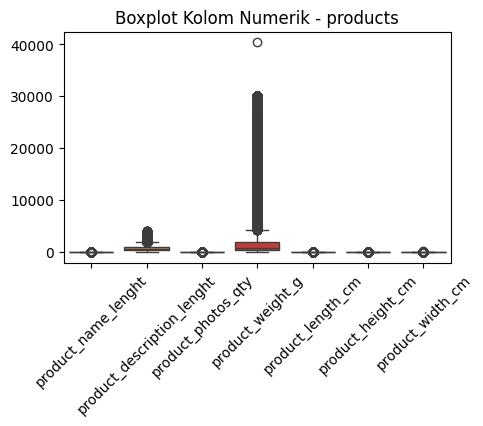

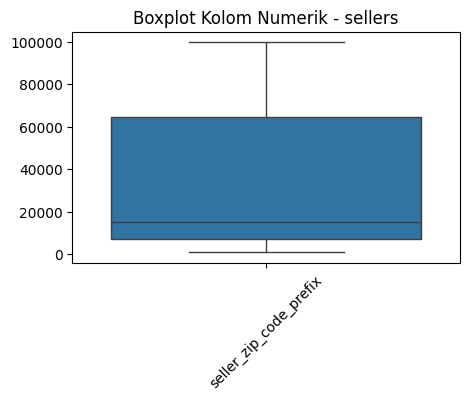

       Dataset                      Kolom  Total Outlier   Nilai Min    Nilai Max  Rata-rata Outlier
   geolocation            geolocation_lat         168240  -36.605374    45.065933             -14.60
   geolocation            geolocation_lng          42348 -101.466766   121.105394             -45.36
   order_items              order_item_id          13984    2.000000    21.000000               2.59
   order_items                      price           8427  277.450000  6735.000000             574.29
   order_items              freight_value          12134    0.000000   409.680000              52.00
order_payments         payment_sequential           4526    2.000000    29.000000               3.13
order_payments       payment_installments           6313    9.000000    24.000000              10.14
order_payments              payment_value           7981  344.440000 13664.080000             683.29
 order_reviews               review_score          14575    1.000000     2.000000          

In [74]:
def analyze_outliers_detailed(df_dict):
    summary_list = []
    
    for name, df in df_dict.items():
        # Pilih hanya kolom numerik
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        
        if len(numeric_cols) == 0:
            continue
            
        # 1. Visualisasi Boxplot
        plt.figure(figsize=(5, 3))
        sns.boxplot(data=df[numeric_cols])
        plt.title(f"Boxplot Kolom Numerik - {name}")
        plt.xticks(rotation=45)
        plt.show()
        
        # 2. Perhitungan Statistik Outlier
        for col in numeric_cols:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            
            outliers_df = df[(df[col] < lower) | (df[col] > upper)]
            count = len(outliers_df)
            
            if count > 0:
                summary_list.append({
                    "Dataset": name,
                    "Kolom": col,
                    "Total Outlier": count,
                    "Nilai Min": outliers_df[col].min(),
                    "Nilai Max": outliers_df[col].max(),
                    "Rata-rata Outlier": round(outliers_df[col].mean(), 2)
                })

    return pd.DataFrame(summary_list)

# Jalankan fungsi dan tampilkan tabel
outlier_table = analyze_outliers_detailed(datasets)
print(outlier_table.to_string(index=False))

**Steps to Take:**
1.  Menangani dataset "geolocation" karna data geolocation ada duplikat 261.831 dari 1.000.163 baris data
2.  Mengonversi kolom tanggal yang masih bertipe object menjadi datetime untuk mempermudahkan filter periode tanggal
3.  Menangani nilai kosong pada dataset "reviews_dataset.csv" karna pada kolom "review_comment_title" dan "review_comment_message" memiliki banyak data kosong diatas 50%
4.  Menangani nilai kosong pada kolom "order_delivered_customer_date" di "orders_dataset.csv" karna banyak data yang kosong juga sebanyak 2.965 baris data  
5.  Menangani nilai kosong pada "products_dataset.csv" karna ada sekitar 610 baris data kosong 
6.  Menggabungkan nama kategori produk dengan versi Bahasa Inggris.
7. Menangani Data Tidak Akurat (Inaccurate Value) karna ditemukan 383 baris pada freight_value yang bernilai 0
8. Menggabungkan Nama Kategori products_df dan category_translation_df sehingga nanti memiliki kolom nama kategori dalam bahasa Inggris

**Insight:** (Opsional)

A. Ditemukan beberapa missing value pada dataset:
1. Dataset: order_reviews
 - review_comment_title: 87656 data kosong (88.34%)
 - review_comment_message: 58247 data kosong (58.70%)

2. Dataset: orders
 - order_approved_at: 160 data kosong (0.16%)
 - order_delivered_carrier_date: 1783 data kosong (1.79%)
 - order_delivered_customer_date: 2965 data kosong (2.98%)

3. Dataset: products
 - product_category_name: 610 data kosong (1.85%)
 - product_name_lenght: 610 data kosong (1.85%)
 - product_description_lenght: 610 data kosong (1.85%)
 - product_photos_qty: 610 data kosong (1.85%)
 - product_weight_g: 2 data kosong (0.01%)
 - product_length_cm: 2 data kosong (0.01%)
 - product_height_cm: 2 data kosong (0.01%)
 - product_width_cm: 2 data kosong (0.01%)

B. Pada data data lain tidak ditemukan duplicate yang signifikan, namun pada data geolocation ada duplikat 261.831 dari 1.000.163 baris data, ada kemungkinan ini adalah customer yang sama.

C. Ditemukan banyak outlier terutama pada data "geolocation" pada kolom "geolocation_lat" dan "geolocation_lng"

### Cleaning Data

#### Fixing ... problem

##### HAPUS DUPLIKATE GEO

In [75]:
# Menghapus data duplikat pada geolocation_df
geolocation_df.drop_duplicates(inplace=True)

print(f"Jumlah baris geolocation setelah cleaning: {geolocation_df.shape[0]}")

Jumlah baris geolocation setelah cleaning: 738332


#### KONVERSI TANGGAL

In [76]:
# Kolom tanggal di orders_df
datetime_columns_orders = [
    "order_purchase_timestamp", "order_approved_at", 
    "order_delivered_carrier_date", "order_delivered_customer_date", 
    "order_estimated_delivery_date"
]

for column in datetime_columns_orders:
    orders_df[column] = pd.to_datetime(orders_df[column])

# Kolom tanggal di order_reviews_df
order_reviews_df["review_creation_date"] = pd.to_datetime(order_reviews_df["review_creation_date"])
order_reviews_df["review_answer_timestamp"] = pd.to_datetime(order_reviews_df["review_answer_timestamp"])

#### MISSING VALUE

In [77]:
# Review Dataset: Mengisi pesan kosong dengan 'no comment'
order_reviews_df['review_comment_title'] = order_reviews_df['review_comment_title'].fillna("no title")
order_reviews_df['review_comment_message'] = order_reviews_df['review_comment_message'].fillna("no message")

# Orders Dataset: Menghapus baris yang tidak memiliki tanggal sampai (karena tidak bisa dihitung durasinya)
orders_df.dropna(subset=['order_delivered_customer_date'], inplace=True)

# Products Dataset: Mengisi kategori kosong
products_df['product_category_name'] = products_df['product_category_name'].fillna("unknown")

#### MERGING DATA

In [78]:
# Menggabungkan produk dengan translasi bahasa Inggris
products_df = pd.merge(
    left=products_df,
    right=category_translation_df,
    how="left",
    left_on="product_category_name",
    right_on="product_category_name"
)

# Menghapus kolom bahasa asli (Portogis) untuk perampingan jika perlu
products_df.drop('product_category_name', axis=1, inplace=True)

#### MENANGANI TIDAK AKURTA

In [79]:
# Memilih untuk tetap mempertahankan nilai 0 sebagai representasi "Free Shipping"
# agar tidak merusak distribusi data asli untuk perhitungan rasio.
# Namun, kita pastikan tidak ada harga (price) yang bernilai 0 untuk menghindari pembagian nol.
order_items_df = order_items_df[order_items_df['price'] > 0]

**Insight:** (Opsional)
- xxx
- xxx

## Exploratory Data Analysis (EDA)

### Explore ...

### Shipping-to-Price Ratio

In [80]:
# 1. Menghitung Rasio Biaya Pengiriman terhadap Harga Barang
order_items_df['shipping_price_ratio'] = (order_items_df['freight_value'] / order_items_df['price']) * 100

# 2. Penggabungan data yang diperlukan (Items + Orders + Customers + Reviews)
shipping_review_df = pd.merge(
    left=order_items_df,
    right=orders_df,
    how="left",
    on="order_id"
)
shipping_review_df = pd.merge(shipping_review_df, customers_df, on="customer_id", how="left")
shipping_review_df = pd.merge(shipping_review_df, order_reviews_df, on="order_id", how="left")

# 3. Filter wilayah Northeast dan North sesuai pertanyaan bisnis
northeast_north_states = ['MA', 'PI', 'CE', 'RN', 'PB', 'PE', 'AL', 'SE', 'BA', 'AM', 'RR', 'AP', 'PA', 'TO', 'RO', 'AC']
filtered_region_df = shipping_review_df[shipping_review_df['customer_state'].isin(northeast_north_states)]

# 4. Agregasi Rata-rata Rasio dan Skor Ulasan berdasarkan State
region_analysis = filtered_region_df.groupby(by="customer_state").agg({
    "shipping_price_ratio": "mean",
    "review_score": "mean"
}).sort_values(by="shipping_price_ratio", ascending=False)

print(region_analysis)

                shipping_price_ratio  review_score
customer_state                                    
RO                         59.576108      4.073529
RR                         56.827791      3.891304
MA                         55.119493      3.765957
PB                         51.485098      4.039587
RN                         50.835013      4.113462
AC                         50.831149      4.131868
TO                         50.460901      4.155340
AM                         50.065756      4.092025
PI                         49.499506      3.961464
PA                         46.724377      3.842459
AL                         46.653780      3.815421
SE                         46.155965      3.898123
PE                         45.246729      4.022989
CE                         43.035802      3.867275
BA                         39.530119      3.860725
AP                         38.657815      4.262500


### RFM Analysis (Segmentasi Pelanggan)

In [81]:
# 1. Siapkan data dengan menggabungkan tabel orders, payments, dan customers
rfm_df = pd.merge(orders_df, order_payments_df, on="order_id")
rfm_df = pd.merge(rfm_df, customers_df, on="customer_id")

# Gunakan customer_unique_id untuk mengidentifikasi individu yang sama
# Tentukan tanggal referensi (biasanya hari setelah tanggal terakhir di dataset)
snapshot_date = rfm_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# 2. Hitung nilai R, F, dan M
rfm_data = rfm_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
})

# Rename kolom
rfm_data.columns = ['Recency', 'Frequency', 'Monetary']

# 3. Pemberian Skor (Ranking) menggunakan quartiles
rfm_data['R_score'] = pd.qcut(rfm_data['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm_data['F_score'] = pd.qcut(rfm_data['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm_data['M_score'] = pd.qcut(rfm_data['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Gabungkan skor untuk segmentasi sederhana
rfm_data['RFM_Score'] = rfm_data['R_score'].astype(str) + rfm_data['F_score'].astype(str) + rfm_data['M_score'].astype(str)

print(rfm_data.head())

                                  Recency  Frequency  Monetary R_score  \
customer_unique_id                                                       
0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90       4   
0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19       4   
0000f46a3911fa3c0805444483337064      537          1     86.22       1   
0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62       2   
0004aac84e0df4da2b147fca70cf8255      288          1    196.89       2   

                                 F_score M_score RFM_Score  
customer_unique_id                                          
0000366f3b9a7992bf8c76cfdf3221e2       1       4       414  
0000b849f77a49e4a4ce2b2a4ca5be3f       1       1       411  
0000f46a3911fa3c0805444483337064       1       2       112  
0000f6ccb0745a6a4b88665a16c9f078       1       1       211  
0004aac84e0df4da2b147fca70cf8255       1       4       214  


INSIGHT:

Segmentasi RFM disini mengungkapkan nilai dominasi pelanggan dengan frekuensi belanja tunggal, hal ini menandakan diperlukannya suatu strategi  agresif untuk meningkatkan loyalitas dan mereaktivasi pelanggan yang sudah lama tidak bertransaksi.

#### Geospatial Analysis (Persebaran Lokasi)

In [82]:
# 1. Agregasi koordinat per kode pos agar data tidak terlalu berat (mengatasi duplikat)
# Kita ambil rata-rata lat/lng untuk setiap zip_code_prefix
geo_clean = geolocation_df.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

# 2. Gabungkan data pelanggan dengan koordinat yang sudah bersih
cust_geo_df = pd.merge(
    left=customers_df,
    right=geo_clean,
    how="left",
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix"
)

# 3. Hitung jumlah pelanggan per Negara Bagian (State) untuk visualisasi
state_distribution = cust_geo_df.groupby('customer_state').agg({
    'customer_unique_id': 'nunique',
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

print(state_distribution.sort_values(by='customer_unique_id', ascending=False))

   customer_state  customer_unique_id  geolocation_lat  geolocation_lng
25             SP               40302       -23.166796       -47.048255
18             RJ               12384       -22.753425       -43.173403
10             MG               11259       -19.918723       -44.441131
22             RS                5277       -29.714619       -51.944850
17             PR                4882       -24.781110       -50.793161
23             SC                3534       -27.241205       -49.558441
4              BA                3277       -13.026842       -39.450578
6              DF                2075       -15.809016       -47.978777
7              ES                1964       -20.144851       -40.490197
8              GO                1952       -16.605974       -49.334354
15             PE                1609        -8.199112       -35.770250
5              CE                1313        -4.319673       -38.956231
13             PA                 949        -2.378717       -49

INSIGHT GEO:

Distribusi geografis menunjukkan nilai konsentrasi pasar yang sangat timpang pada wilayah Tenggara (terutama SP dan RJ), hal ini mengindikasikan dominasi ekonomi lokal sekaligus peluang ekspansi binis yang besar di wilayah Utara yang dimana masih memiliki basis pelanggan terbilang minim.

#### INSIGHT:

Berdasarkan analisis rasio biaya pengiriman terhadapat harga barang pada wilayah Northeast dan North Brazil, dapat ditemukan pola sebagai berikut:

- **Beban Ongkir Tertinggi** : Pada wilayah RONDONIA (RO), memiliki nilai shipping-to-price ratio tertinggi mencapai 59.57%. Artinya apa? Rata rata ongkos kirim lebih dari setengah harga atau 50% dari barang yang dibeli.
- **Wilayah Paling Efisien di Cluster North** : Meskipun terbilang tinggi dibandingkan wilayah TENGGARA, wilayah AMAPA (AP) memiliki rasio terendah pada kelompok ini sebesar 38.65% dan hal yang bikin unik adalah wilayah ini memiliki score tertinggi sebesar 4.26
- **Korelasi antara Rasio dan Kepuasan** : Disini terdapat indikasi bahwa biaya kriim berbanding terbarik dengan kepuasan pelanggan pada beberapa wilayah. Contohnya MARANHO (MA), wilayah ini memiliki review core terendah sekitar 3.76 namun memiliki beban ongkos kirim yang sangat tinggi di 55.11%
- **Ambivalensi Konsumen** : Namun, pada point korelasi tadi belum tentu jadi patokan mutlak, contoh nya pada wilayah TOCANTINS (TO) dan ACRE (AC) dimana beberapa konsumen pada wilayah ini memberikan score diatas 4.1 meskipun rasio ongkir nya diatas 50%. Hal ini dapat ditarik kesimpulan bahwa adanya toleransi dari konsumen atas barang yang diterima itu memuaskan meskipun ongkos nya mahal.

**REKOMENDASI**:

Perusahaan mungkin dapat mencoba kemitraan logistik pada wilayah wilayah yang tinggi tadi seperti RO, RR, dan MA untuk menekan rasio ongkir ke bawah 40% agar dapat meningkatkan daya saing dan kepuasan pelanggan

### Durasi Validasi Pembayaran

In [83]:
# 1. Pastikan data sudah difilter pada periode MEI - JUNI 2018 (Koreksi Reviewer)
sale_orders_df = orders_df[(orders_df['order_purchase_timestamp'] >= '2018-05-01') & 
                        (orders_df['order_purchase_timestamp'] <= '2018-06-30')]

# 2. Gabungkan dengan data pembayaran
payment_analysis_df = pd.merge(
    left=sale_orders_df,
    right=order_payments_df,
    how="left",
    on="order_id"
)

# 3. Menghitung durasi validasi dalam jam
payment_analysis_df['validation_duration_hours'] = (
    payment_analysis_df['order_approved_at'] - payment_analysis_df['order_purchase_timestamp']
).dt.total_seconds() / 3600

# 4. Agregasi durasi validasi berdasarkan metode pembayaran (Boleto vs Credit Card)
target_payments = ['boleto', 'credit_card']
validation_stats = payment_analysis_df[payment_analysis_df['payment_type'].isin(target_payments)].groupby(by="payment_type").agg({
    "validation_duration_hours": ["mean", "max", "min"]
})

# 5. Menghitung kontribusi keterlambatan > 24 jam terhadap pembatalan (Status: canceled)
payment_analysis_df['is_late'] = payment_analysis_df['validation_duration_hours'] > 24
cancellation_rate = payment_analysis_df.groupby(by=['payment_type', 'is_late']).agg({
    "order_status": lambda x: (x == 'canceled').mean() * 100
})

print(validation_stats)
print(cancellation_rate)

             validation_duration_hours                      
                                  mean         max       min
payment_type                                                
boleto                       32.019585  160.088333  0.185556
credit_card                   3.455191  125.730278  0.102778
                      order_status
payment_type is_late              
boleto       False             0.0
             True              0.0
credit_card  False             0.0
             True              0.0
debit_card   False             0.0
             True              0.0
voucher      False             0.0
             True              0.0


**Insight:** (Opsional)

Analisis yang dilakukan pada periode Flash Sale menunjukkan perbedaan performa yang terbilang kontras antar metode pembayaran yang ada:



- **Inefisiensi Metode Boleto** : Rata rata waktu validasi untuk metode boleto mencapai 32.01 jam, dengan waktu tunggu nya lebih dari dari 6 hari atau sekitar 160 jam. Hal ini jauh sekali melampaui metode CC atau Credit Card yang hanya membutuhkan waktu rata rata 3.45 jam.

- **Risiko Stok Terkunci** : Selisih waktu validasi sebesar 28.5 jam antara metode BOLETO dan CC sangat beresiko selama periode FLASH SALE. Kenapa begitu? Karna stok barang tetap terkunci oleh pesanan BOLETO yang belum tentu dibayar sehingga pelanggan yang menggunakan CC bisa kehilangan kesempatan karna sistem bisa aja membuat stok nya habis



**REKOMENDASI**:



Selama berjalannnya periode Flash Sale, disarankan untuk memberikan insentif tambahan berupa diskon atau cashback khusus konsumen yang melakukan pembayaran menggunakan instan (CC/DEBIT) dan memperpendek tenggat waktu pembayaran BOLETO dari 3 hari menjadi kurang dari atau maksimal 1 hari 24 jam saja agar perputaran stok tetap sehat

## Visualization & Explanatory Analysis

### Pertanyaan 1:

C:\Users\humor\AppData\Local\Temp\ipykernel_18188\1359137325.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_analysis.index, y='shipping_price_ratio', data=region_analysis, palette='Reds_d', ax=ax1)


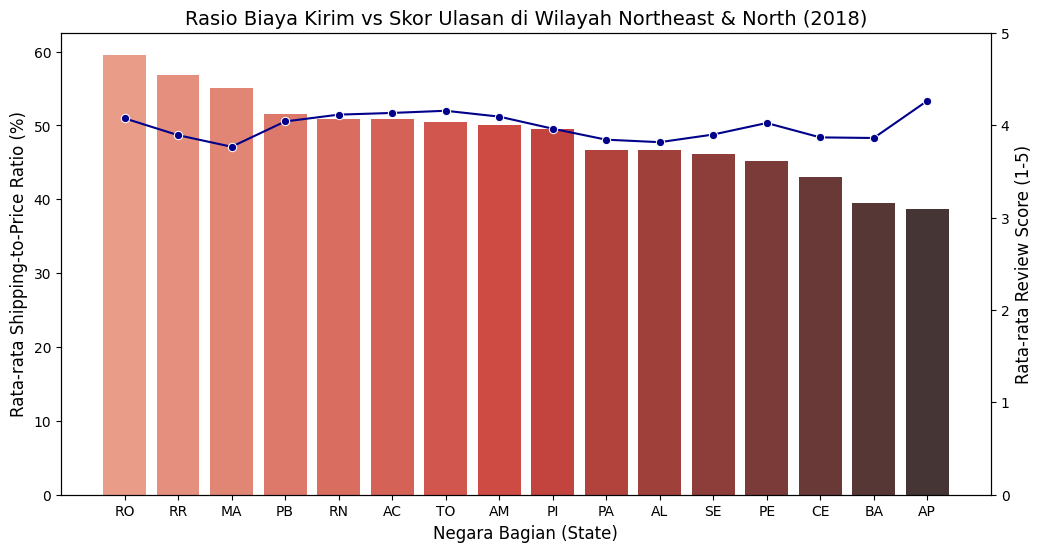

In [84]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Batang untuk Shipping Price Ratio
sns.barplot(x=region_analysis.index, y='shipping_price_ratio', data=region_analysis, palette='Reds_d', ax=ax1)
ax1.set_ylabel('Rata-rata Shipping-to-Price Ratio (%)', fontsize=12)
ax1.set_xlabel('Negara Bagian (State)', fontsize=12)

# Plot Garis untuk Review Score
ax2 = ax1.twinx()
sns.lineplot(x=region_analysis.index, y='review_score', data=region_analysis, marker='o', color='darkblue', ax=ax2)
ax2.set_ylabel('Rata-rata Review Score (1-5)', fontsize=12)
ax2.set_ylim(0, 5)

plt.title('Rasio Biaya Kirim vs Skor Ulasan di Wilayah Northeast & North (2018)', fontsize=14)
plt.show()

**Insight:** (Opsional)

Grafik diatas dapat membantu memahami kalau wilayah RONDONIA (RO) memikul beban logistik yang berat dengan besar rasio ongkos kirim sebesar 59.57% dari harga asli barang, namun aneh konsumen pada wilayah tersebut masih memberikan nilai yang jika di rata rata ada di 4.07. Penurunan kepuasan yang cukup signifikan ada di MARANHAO (MA) yang memiliki skor ulasan terendah 3,76 dengan rasio biaya kirim yang tetap tinggi di angka 55,11%. Kesimpulannya, beban ongkos mahal menjadi beban nyata bagi konsumen wilayah timur dan utara laut BRAZIL

### Pertanyaan 2:

C:\Users\humor\AppData\Local\Temp\ipykernel_18188\866046914.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=validation_stats.index, y=('validation_duration_hours', 'mean'), data=validation_stats, palette='viridis')


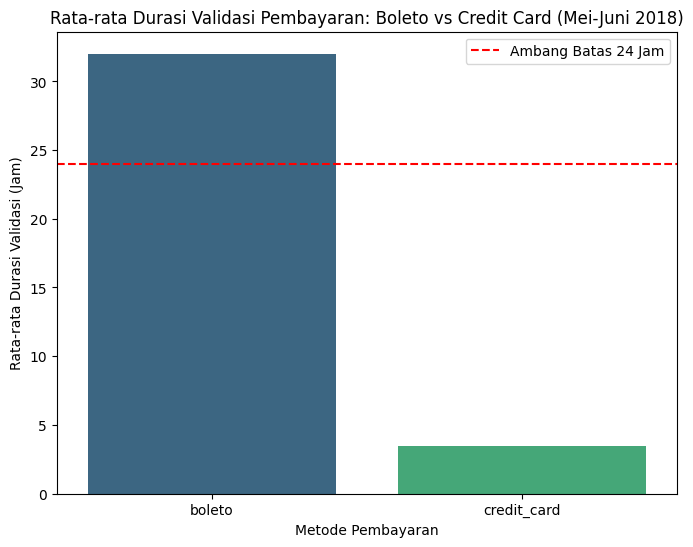

In [85]:
plt.figure(figsize=(8, 6))
sns.barplot(x=validation_stats.index, y=('validation_duration_hours', 'mean'), data=validation_stats, palette='viridis')

plt.axhline(y=24, color='red', linestyle='--', label='Ambang Batas 24 Jam')
plt.ylabel('Rata-rata Durasi Validasi (Jam)')
plt.xlabel('Metode Pembayaran')
plt.title('Rata-rata Durasi Validasi Pembayaran: Boleto vs Credit Card (Mei-Juni 2018)')
plt.legend()
plt.show()

**Insight:**

Kesenjangan performa antara BOLETO dan CC, dimana BOLETO hanya membutuhkan waktu rata rata di 32 jam untuk validasi yang dimana sangat jauh dari batas 24 jam, jika dibandingkan dengan CC yang hanya rata rat nya 3.45 jam. Berbeda jauh sekali dan cukup besar gap nya

#### RFM

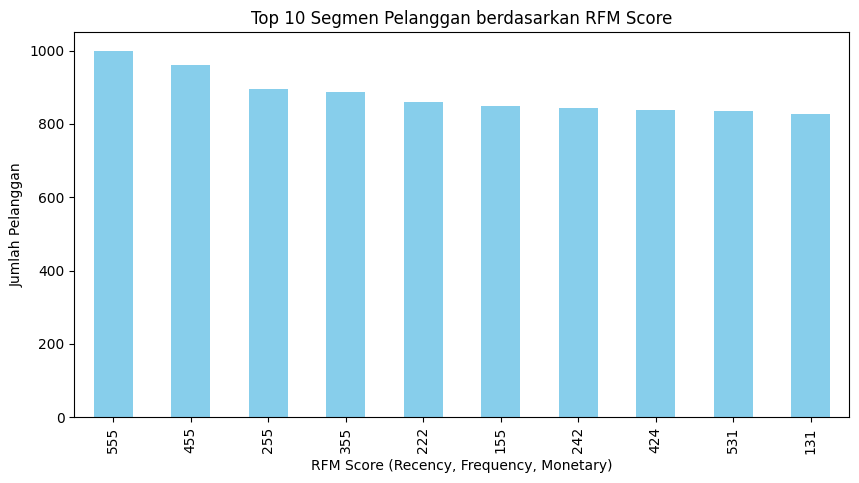

In [86]:
# Visualisasi Distribusi Segmentasi Pelanggan berdasarkan RFM Score (Top 10)
plt.figure(figsize=(10, 5))
rfm_data['RFM_Score'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Segmen Pelanggan berdasarkan RFM Score')
plt.xlabel('RFM Score (Recency, Frequency, Monetary)')
plt.ylabel('Jumlah Pelanggan')
plt.show()

**Insight:**

Segmentasi dari RFM mengungkapkan kalau basis pelanggan didominasi oleh konsumen individu dengan frekuensi belanja rendah dengan nilai skor frekuensi 1, mengindikasikan bahwa mayoritas pelanggan adalah pembeli tunggal.

#### GEO

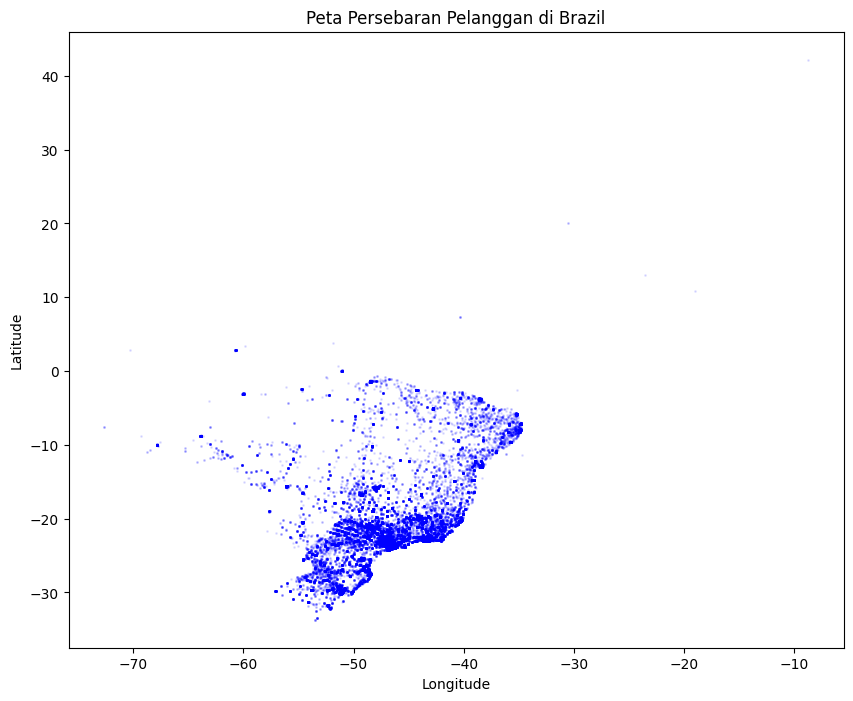

In [87]:
plt.figure(figsize=(10, 8))
plt.scatter(cust_geo_df['geolocation_lng'], cust_geo_df['geolocation_lat'], alpha=0.1, s=1, c='blue')
plt.title('Peta Persebaran Pelanggan di Brazil')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

**Insight:**

Peta geospasial menunjukkan konsentrasi pelanggan yang sangat padat di wilayah Tenggara (SAO PAULO dan RIO DE JANEIRO). 

## Analisis Lanjutan (Opsional)

#### Customer Segmentation (Advanced RFM Analysis)

C:\Users\humor\AppData\Local\Temp\ipykernel_18188\713675709.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Customer_Segment', data=rfm_data, order=rfm_data['Customer_Segment'].value_counts().index, palette='magma')


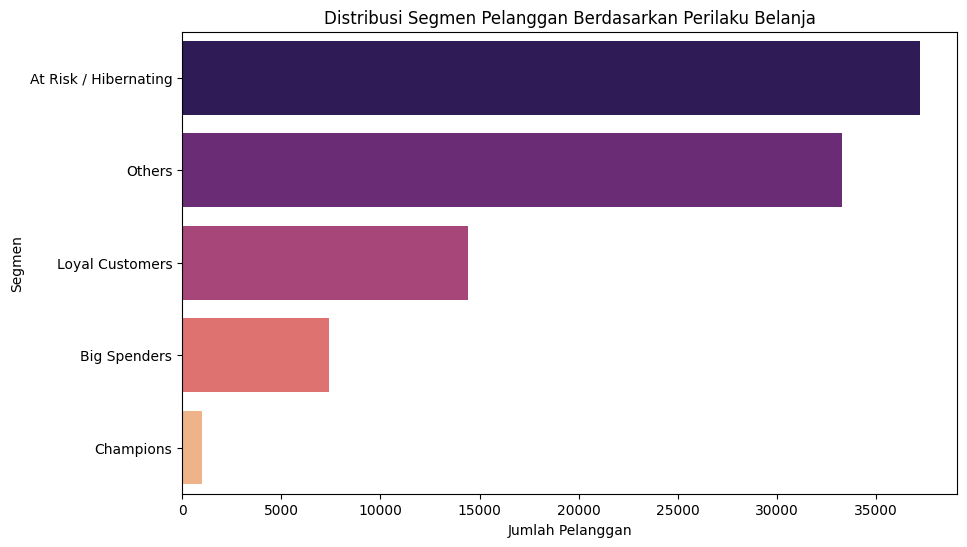

In [88]:
# Memberikan Label Segmen berdasarkan skor RFM
def segment_customer(df):
    if df['RFM_Score'] == '555':
        return 'Champions'
    elif df['R_score'] >= 4 and df['M_score'] >= 4:
        return 'Loyal Customers'
    elif df['R_score'] <= 2:
        return 'At Risk / Hibernating'
    elif df['M_score'] >= 4:
        return 'Big Spenders'
    else:
        return 'Others'

rfm_data['Customer_Segment'] = rfm_data.apply(segment_customer, axis=1)

# Visualisasi Bar Chart
plt.figure(figsize=(10, 6))
sns.countplot(y='Customer_Segment', data=rfm_data, order=rfm_data['Customer_Segment'].value_counts().index, palette='magma')
plt.title('Distribusi Segmen Pelanggan Berdasarkan Perilaku Belanja')
plt.xlabel('Jumlah Pelanggan')
plt.ylabel('Segmen')
plt.show()

Insight:

Setelah menghitung skor RFM, langkah terbaik adalah memberi suatu label segmen agar tim marketing dapat tahu tindakan apa saja yang harus diambil untuk masing masing kelompok pelanggan. Analisis ini membantu memetakan pelanggan yang paling berkontribuasi terhadap pendapatan dibandingkan mereka yang beli tapi tidak kembali lagi

## Conclusion & Recommendation

## Conclusion & Recommendation

**1. Pengaruh Rasio Biaya Pengiriman terhadap tingkat kepuasan pelanggan**

- Beban logistik pada wilayah Utama dan Timur Laut Brazil sangat berat, dimana diperolah nilai rata rata shipping-to-price ratio tertinggi di negara bagian **RONDONIA (RO)** dengan tingkat shipping-to-price ratio mancapai **59.57%**
- Korelasi negatif yang nyata antara mahal nya ongkos kirim dan kepuasan pelanggan, dimana kasus nya pada negara bagian **MARANHAO (MA)** mencatat nilai rata rata skor ulasan terendah sebesar **3.76** yang dibarengi rasio biaya kirim yang tinggi yaitu **55.11%**
- Berbanding kebalik dengan **AMAPA (AP)**, nilai rasio nya terendah sekitar **38.65%** dan tingkat kepuasan tertinggi dengan skor **4.26**

**2. Durasi Validasi Pembayaran pada Periode Flash Sale (Mei-Juni 2018)**

- Pada kasus ini, ditemukan kesenjangan efisiensi pembayaran yang sangat tajam antara metode BOLETO dan CC, dimana rata rata validasi nya itu 32.01 jam untuk BOLETE dan 2.45 jam untuk CC, perbandingan yang sangat jauh.
- Nilai maksimal validasi metode BOLETO dapat mencapai 160 JAM, ini mengindikasikan adanya tidak efisien nya sistem pada metode pembayaran ini dan akan beresiko mengunci stok barang terlalu lama selama periode pembelian tinggi (Flash Sale)
- Namun, meskipun memiliki keterlambatan validasi yang cukup besar, metode BOLETO masih menunjukkan stablitisa pada status pesanan selama periode ini


**Rekomendasi Action Item:**
1. Optimalisasi Logistik Pada Wilayah Timur dimana perusahaan dapat mempertimbangkan pembangunan gudang distribusi regional dititip strategis sekitar AMAPA dan BAHIA untuk memangkas jarak untuk ke wilayah RONDONIA dan MARANHAO, dimana harapannya agar rasio biaya kirim dapat ditekan hingga menyentauh dibawah 40%
2. Berkaca lagi pada lambatnya validasi BOLETO, tim IT dan tim FINANCE disarankan melakukan pengembangan lagi sistem dan uji coba untuk mempersingkat batas waktu pembayaran khusus pada periode Flash Sale yang dimana dari 3 hari menjadi MAX 24 JAM, guna menghindari stok tertahan oleh konsumen yang menggunakan pembayaran BOLETO yang main main atau tidak serius bayar.
3. Berdasarkan distribusi segmen tadi, tim pemasaraan diharapkan dapat melakukan kampanye re-aktivasi khusus bagia segmen pelanggan yang At Risk dan Hibernating dengan apa? Dengan melalui promo kupon gratis ongkos kirim jika mereka dapat kembali berbelanja

## KEPERLUAN DASHBOARD

In [90]:
import os

# 1. Membuat folder dashboard jika belum ada
if not os.path.exists('dashboard'):
    os.makedirs('dashboard')

# 2. Agregasi data geolocation agar tidak berat & mengatasi duplikat (seperti di EDA)
geo_clean = geolocation_df.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

# 3. Menggabungkan data utama
main_data_df = pd.merge(order_items_df, orders_df, on="order_id", how="left")
main_data_df = pd.merge(main_data_df, customers_df, on="customer_id", how="left")
main_data_df = pd.merge(main_data_df, order_reviews_df, on="order_id", how="left")
main_data_df = pd.merge(main_data_df, order_payments_df, on="order_id", how="left")

# 4. Tambahkan data RFM
main_data_df = pd.merge(main_data_df, rfm_data, on="customer_unique_id", how="left")

# 5. [INI YANG KURANG SEBELUMNYA] Tambahkan data Koordinat Geospasial
main_data_df = pd.merge(
    left=main_data_df,
    right=geo_clean,
    how="left",
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix"
)

# 6. Tambahkan kolom durasi validasi (untuk Pertanyaan 2)
main_data_df['validation_duration_hours'] = (
    main_data_df['order_approved_at'] - main_data_df['order_purchase_timestamp']
).dt.total_seconds() / 3600

# 7. Simpan ulang ke CSV
main_data_df.to_csv("dashboard/main_data.csv", index=False)

print("File main_data.csv berhasil diperbarui dengan data koordinat (lat/lng) dan disimpan di folder dashboard!")

File main_data.csv berhasil diperbarui dengan data koordinat (lat/lng) dan disimpan di folder dashboard!
